# Image Classification with Convolutional Neural Networks

## Using Keras and TensorFlow to Build CNNs

In [1]:
from tensorflow.keras.layers import Conv2D, Dense, Flatten, MaxPooling2D
from tensorflow.keras.models import Sequential

In [2]:
model = Sequential()
model.add(Conv2D(32, (3, 3), activation="relu", input_shape=(28, 28, 1)))
model.add(MaxPooling2D(2, 2))
model.add(Conv2D(64, (3, 3), activation="relu"))
model.add(MaxPooling2D(2, 2))
model.add(Flatten())
model.add(Dense(128, activation="relu"))
model.add(Dense(10, activation="softmax"))
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 26, 26, 32)        320       
                                                                 
 max_pooling2d (MaxPooling2  (None, 13, 13, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 11, 11, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 5, 5, 64)          0         
 g2D)                                                            
                                                                 
 flatten (Flatten)           (None, 1600)              0         
                                                                 
 dense (Dense)               (None, 128)               2

In [3]:
from tensorflow.keras.datasets import mnist

(train_images, y_train), (test_images, y_test) = mnist.load_data()
X_train = train_images.reshape(60000, 28, 28, 1) / 255
X_test = test_images.reshape(10000, 28, 28, 1) / 255

11490434/11490434 [==============================] - 2s 0us/step


In [4]:
from tensorflow.keras.layers import Conv2D, Dense, Flatten, MaxPooling2D
from tensorflow.keras.models import Sequential

model = Sequential()
model.add(Conv2D(32, (3, 3), activation="relu", input_shape=(28, 28, 1)))
model.add(MaxPooling2D(2, 2))
model.add(Conv2D(64, (3, 3), activation="relu"))
model.add(MaxPooling2D(2, 2))
model.add(Flatten())
model.add(Dense(128, activation="relu"))
model.add(Dense(10, activation="softmax"))
model.compile(
    optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"]
)
model.summary(line_length=80)

Model: "sequential_1"
________________________________________________________________________________
 Layer (type)                       Output Shape                    Param #     
 conv2d_2 (Conv2D)                  (None, 26, 26, 32)              320         
                                                                                
 max_pooling2d_2 (MaxPooling2D)     (None, 13, 13, 32)              0           
                                                                                
 conv2d_3 (Conv2D)                  (None, 11, 11, 64)              18496       
                                                                                
 max_pooling2d_3 (MaxPooling2D)     (None, 5, 5, 64)                0           
                                                                                
 flatten_1 (Flatten)                (None, 1600)                    0           
                                                                                
 dense

In [5]:
hist = model.fit(
    X_train, y_train, validation_data=(X_test, y_test), epochs=10, batch_size=50
)

Epoch 1/10
1200/1200 [==============================] - 6s 5ms/step - loss: 0.1487 - accuracy: 0.9553 - val_loss: 0.0480 - val_accuracy: 0.9838
Epoch 2/10
1200/1200 [==============================] - 6s 5ms/step - loss: 0.0455 - accuracy: 0.9864 - val_loss: 0.0385 - val_accuracy: 0.9869
Epoch 3/10
1200/1200 [==============================] - 6s 5ms/step - loss: 0.0308 - accuracy: 0.9906 - val_loss: 0.0321 - val_accuracy: 0.9893
Epoch 4/10
1200/1200 [==============================] - 6s 5ms/step - loss: 0.0227 - accuracy: 0.9927 - val_loss: 0.0292 - val_accuracy: 0.9912
Epoch 5/10
1200/1200 [==============================] - 6s 5ms/step - loss: 0.0183 - accuracy: 0.9941 - val_loss: 0.0276 - val_accuracy: 0.9909
Epoch 6/10
1200/1200 [==============================] - 6s 5ms/step - loss: 0.0137 - accuracy: 0.9956 - val_loss: 0.0349 - val_accuracy: 0.9895
Epoch 7/10
1200/1200 [==============================] - 6s 5ms/step - loss: 0.0107 - accuracy: 0.9966 - val_loss: 0.0311 - val_accuracy:

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()

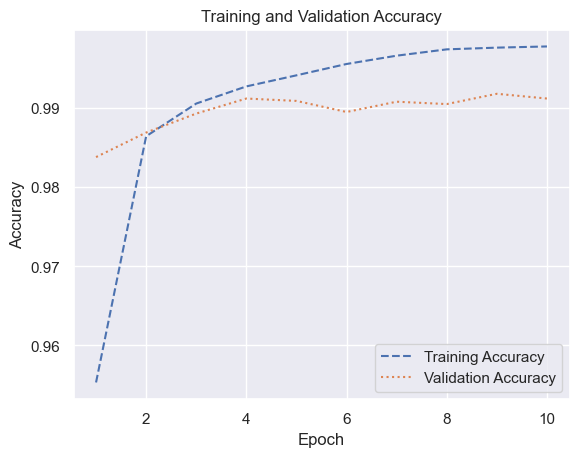

In [8]:
acc = hist.history["accuracy"]
val_acc = hist.history["val_accuracy"]
epochs = range(1, len(acc) + 1)

plt.plot(epochs, acc, "--", label="Training Accuracy")
plt.plot(epochs, val_acc, ":", label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(loc="lower right");

## Training a CNN to Recognize Arctic Wildlife

In [12]:
from pathlib import Path

import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

In [59]:
def load_images_from_path(path, label):
    images, labels = [], []

    for file in os.listdir(path):
        img = image.load_img(Path(path) / file, target_size=(224, 224, 3))
        images.append(image.img_to_array(img))
        labels.append((label))

    return images, labels


def show_images(images):
    fig, axes = plt.subplots(
        1, 8, figsize=(20, 20), subplot_kw={"xticks": [], "yticks": []}
    )

    for i, ax in enumerate(axes.flat):
        ax.imshow(images[i] / 255)


X_train, y_train, X_test, y_test = [], [], [], []

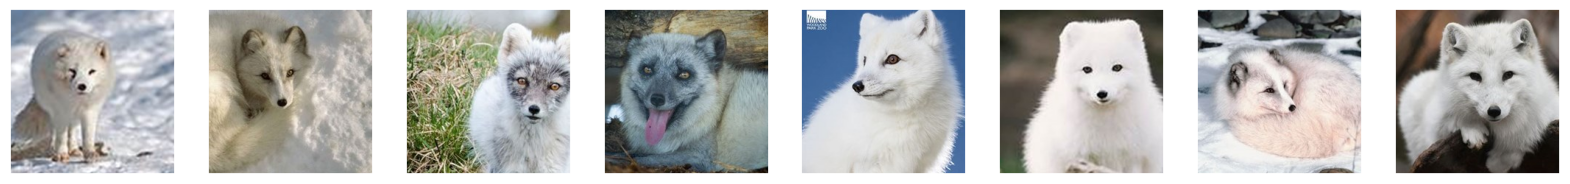

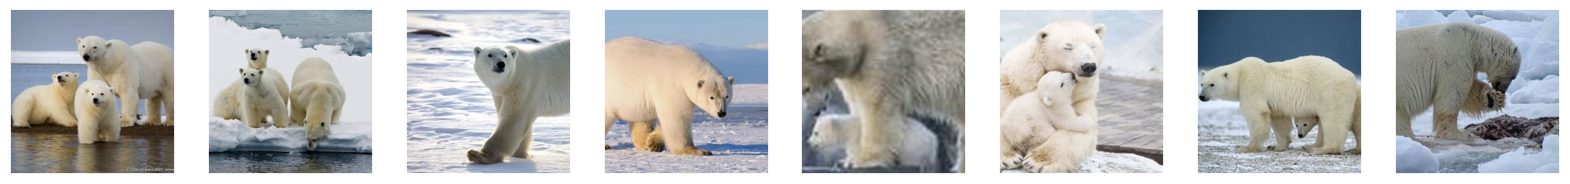

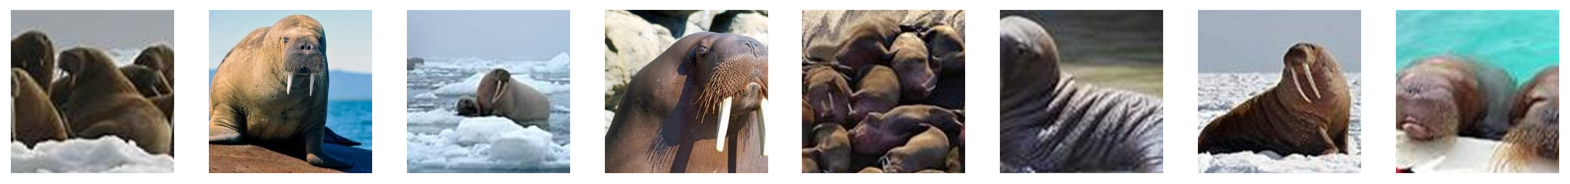

In [60]:
for i, animal in enumerate(["arctic_fox", "polar_bear", "walrus"]):
    images, labels = load_images_from_path(Path("Wildlife/train") / animal, i)
    X_train += images
    y_train += labels

    show_images(images)

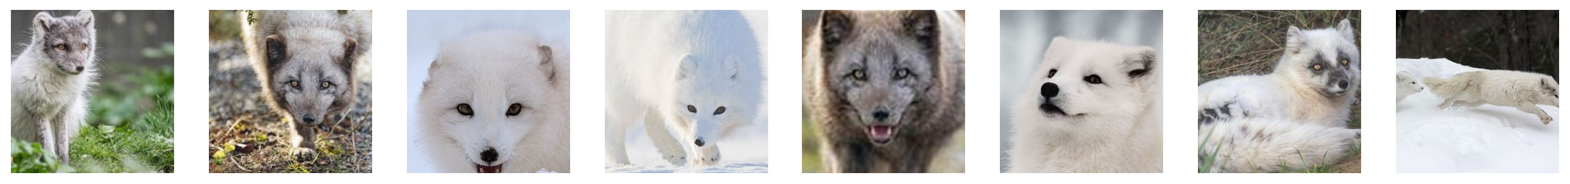

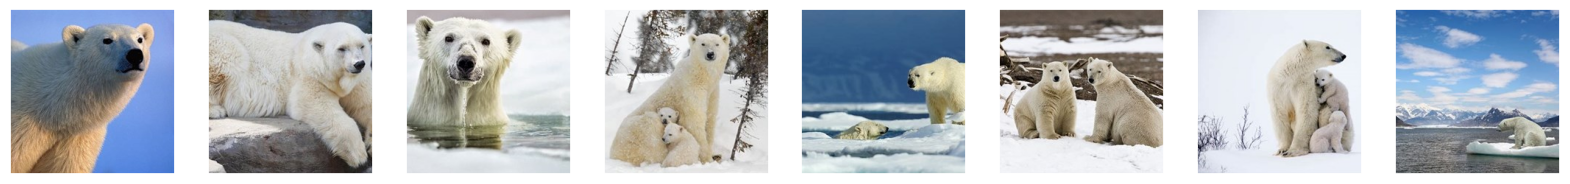

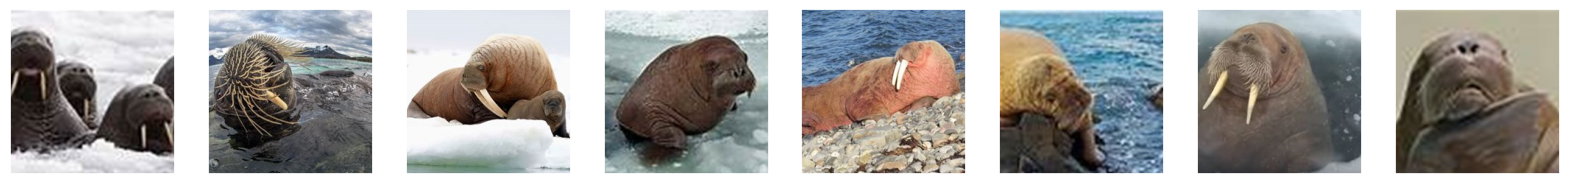

In [61]:
for i, animal in enumerate(["arctic_fox", "polar_bear", "walrus"]):
    images, labels = load_images_from_path(Path("Wildlife/test") / animal, i)
    X_test += images
    y_test += labels

    show_images(images)

In [22]:
import numpy as np

X_train = np.array(X_train) / 255
X_test = np.array(X_test) / 255

y_train = np.array(y_train)
y_test = np.array(y_test)

In [23]:
from tensorflow.keras.layers import Conv2D, Dense, Flatten, MaxPooling2D
from tensorflow.keras.models import Sequential

model = Sequential()
model.add(Conv2D(32, (3, 3), activation="relu", input_shape=(224, 224, 3)))
model.add(MaxPooling2D(2, 2))
model.add(Conv2D(64, (3, 3), activation="relu"))
model.add(MaxPooling2D(2, 2))
model.add(Conv2D(64, (3, 3), activation="relu"))
model.add(MaxPooling2D(2, 2))
model.add(Conv2D(128, (3, 3), activation="relu"))
model.add(MaxPooling2D(2, 2))
model.add(Conv2D(128, (3, 3), activation="relu"))
model.add(MaxPooling2D(2, 2))
model.add(Flatten())
model.add(Dense(1024, activation="relu"))
model.add(Dense(3, activation="softmax"))
model.compile(
    optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"]
)
model.summary(line_length=80)

Model: "sequential_2"
________________________________________________________________________________
 Layer (type)                       Output Shape                    Param #     
 conv2d_4 (Conv2D)                  (None, 222, 222, 32)            896         
                                                                                
 max_pooling2d_4 (MaxPooling2D)     (None, 111, 111, 32)            0           
                                                                                
 conv2d_5 (Conv2D)                  (None, 109, 109, 64)            18496       
                                                                                
 max_pooling2d_5 (MaxPooling2D)     (None, 54, 54, 64)              0           
                                                                                
 conv2d_6 (Conv2D)                  (None, 52, 52, 64)              36928       
                                                                                
 max_p

In [24]:
hist = model.fit(
    X_train, y_train, validation_data=(X_test, y_test), batch_size=10, epochs=20
)

Epoch 1/20
30/30 [==============================] - 3s 105ms/step - loss: 1.1083 - accuracy: 0.3367 - val_loss: 1.0959 - val_accuracy: 0.3333
Epoch 2/20
30/30 [==============================] - 3s 103ms/step - loss: 1.0399 - accuracy: 0.3900 - val_loss: 0.9290 - val_accuracy: 0.5167
Epoch 3/20
30/30 [==============================] - 3s 103ms/step - loss: 0.9856 - accuracy: 0.5367 - val_loss: 0.8883 - val_accuracy: 0.5833
Epoch 4/20
30/30 [==============================] - 3s 103ms/step - loss: 0.7790 - accuracy: 0.6267 - val_loss: 0.7932 - val_accuracy: 0.6333
Epoch 5/20
30/30 [==============================] - 3s 104ms/step - loss: 0.7221 - accuracy: 0.6467 - val_loss: 1.2548 - val_accuracy: 0.4083
Epoch 6/20
30/30 [==============================] - 3s 102ms/step - loss: 0.7762 - accuracy: 0.6433 - val_loss: 0.7859 - val_accuracy: 0.6750
Epoch 7/20
30/30 [==============================] - 3s 102ms/step - loss: 0.6523 - accuracy: 0.6700 - val_loss: 0.8244 - val_accuracy: 0.6500
Epoch 

In [25]:
import seaborn as sns

sns.set_theme()

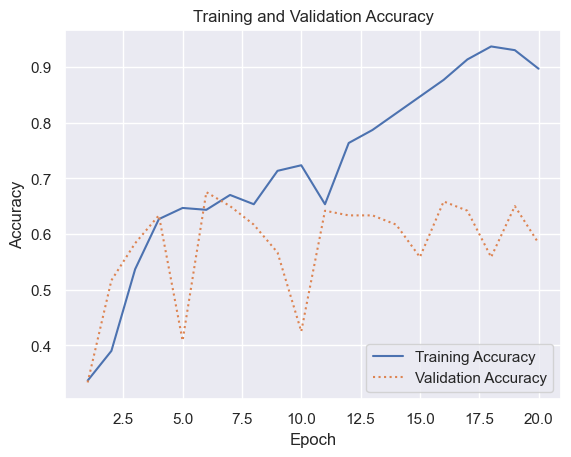

In [37]:
acc = hist.history["accuracy"]
val_acc = hist.history["val_accuracy"]
epochs = range(1, len(acc) + 1)

plt.plot(epochs, acc, "-", label="Training Accuracy")
plt.plot(epochs, val_acc, ":", label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(loc="lower right");